# 1. Import required libraries.
 NumPy is used for numerical operations.

 Matplotlib is used to visualize image data.

 TensorFlow.Keras is used to build and train the neural network.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import models, layers, optimizers

# 2.Load the MNIST dataset.
x_train and x_test are NumPy arrays of shape (num_samples, 28, 28).

Each image is represented as a 28x28 matrix of pixel values (0–255).

y_train and y_test contain integer labels from 0 to 9.

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


# 3. Display one example image from the training set.
The image is stored as a 28x28 NumPy array.


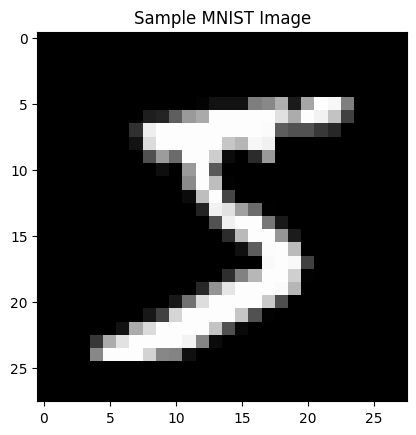

In [ ]:

plt.imshow(x_train[0], cmap='gray')
plt.title("Sample MNIST Image")
plt.show()

# 4. Print the numeric representation of the same image.
Each pixel value ranges from 0 (black) to 255 (white).

This demonstrates how images are stored as numerical data.

In [ ]:
print("Numeric representation of the image:")
print(x_train[0])

Numeric representation of the image:
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0  

# 5. Normalize pixel values to the range [0, 1].
This improves the stability of gradient descent during training because large input values can cause unstable updates.


In [ ]:

x_train = x_train / 255.0
x_test = x_test / 255.0

# 6. Reshape each 28x28 image into a 784-dimensional vector.
A feedforward neural network requires 1D input.
Therefore, each pixel becomes one input neuron.

In [ ]:


x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

print("New training shape:", x_train.shape)

New training shape: (60000, 784)


# 7. Build a simple feedforward neural network using Sequential model.
Input layer: 784 neurons (one per pixel).

Hidden layer: 128 neurons with ReLU activation.

Output layer: 10 neurons with softmax activation,
representing probability distribution over 10 digit classes.

In [ ]:
model = models.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 8. Define the optimizer as Stochastic Gradient Descent (SGD).
The learning rate determines the size of weight updates.

If the learning rate is too large, training may diverge.

If it is too small, training will be very slow.


In [ ]:
sgd = optimizers.SGD(learning_rate=0.01)


# 9. Compile the model.
The loss function measures how different the predicted output is from the true labels. For multi-class classification, we use sparse_categorical_crossentropy. During training, SGD updates the weights to minimize this loss.


In [ ]:
model.compile(
    optimizer=sgd,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 10. Train the neural network on the training data.
Each epoch means the model processes the entire training dataset once. During training, the model adjusts its weights using gradients computed from the loss function.



In [ ]:
model.fit(x_train, y_train, epochs=5, batch_size=32)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7362 - loss: 1.0215
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9032 - loss: 0.3494
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9198 - loss: 0.2876
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9274 - loss: 0.2598
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9330 - loss: 0.2390


# 11. Use the trained model to predict one test image.
The output is a probability distribution across 10 classes.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Predicted class: 7
True label: 7


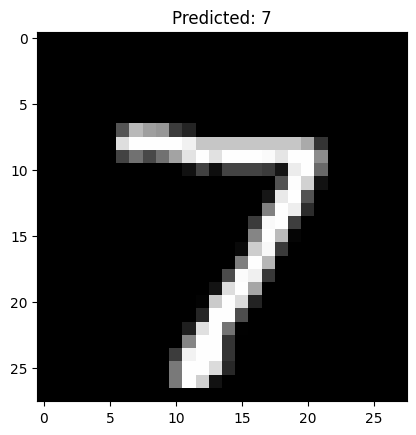

In [ ]:
sample = x_test[0].reshape(1, 784)
prediction = model.predict(sample)

predicted_class = np.argmax(prediction)

print("Predicted class:", predicted_class)
print("True label:", y_test[0])

# Display the test image
plt.imshow(x_test[0].reshape(28, 28), cmap='gray')
plt.title(f"Predicted: {predicted_class}")
plt.show()

# 12. Summary
The trained feedforward neural network successfully predicted the test image as digit 7, which matches the true label. The output layer contains 10 neurons with a softmax activation function, producing a probability distribution across the ten digit classes (0–9). The model selects the class with the highest probability using argmax. This confirms that the data preprocessing (normalization and reshaping), model architecture, and stochastic gradient descent training were implemented correctly.